### Adressing comments on phase 2

In [2]:
import pandas as pd
df = pd.read_csv("cleaned_flight_data.csv")
pd.set_option('display.max_columns', None)
df.head()

,FL_DATE,AIRLINE_CODE,FL_NUMBER,ORIGIN,DEST,DEP_DELAY,TAXI_OUT,WHEELS_OFF,WHEELS_ON,TAXI_IN,ARR_DELAY,IS_CANCELLED,CANCELLATION_CODE,DIVERTED,CRS_ELAPSED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,DELAY_DUE_CARRIER,DELAY_DUE_WEATHER,DELAY_DUE_NAS,DELAY_DUE_SECURITY,DELAY_DUE_LATE_AIRCRAFT,YEAR,MONTH,DAY_OF_WEEK,CRS_DEP_TIME_HOUR,CRS_DEP_TIME_MINUTE,DEP_TIME_HOUR,DEP_TIME_MINUTE,CRS_ARR_TIME_HOUR,CRS_ARR_TIME_MINUTE,ARR_TIME_HOUR,ARR_TIME_MINUTE,IS_DELAYED
0,2019-01-09,14,1562,131,123,-4.0,19.0,1210.0,1443.0,4.0,-14.0,0.0,4,0.0,186.0,176.0,153.0,1065.0,0.0,0.0,0.0,0.0,0.0,2019,1,2,11,55,11.0,51.0,15.0,1.0,14.0,47.0,0
1,2022-11-19,4,1149,247,323,-6.0,9.0,2123.0,2232.0,38.0,-5.0,0.0,4,0.0,235.0,236.0,189.0,1399.0,0.0,0.0,0.0,0.0,0.0,2022,11,5,21,20,21.0,14.0,23.0,15.0,23.0,10.0,0
2,2022-07-22,14,459,99,247,6.0,20.0,1020.0,1247.0,5.0,0.0,0.0,4,0.0,118.0,112.0,87.0,680.0,0.0,0.0,0.0,0.0,0.0,2022,7,4,9,54,10.0,0.0,12.0,52.0,12.0,52.0,0
3,2023-03-06,4,2295,247,325,-1.0,27.0,1635.0,1844.0,9.0,24.0,0.0,4,0.0,260.0,285.0,249.0,1589.0,0.0,0.0,24.0,0.0,0.0,2023,3,0,16,9,16.0,8.0,18.0,29.0,18.0,53.0,1
4,2020-02-23,10,407,223,100,-2.0,15.0,1853.0,2026.0,14.0,-1.0,0.0,4,0.0,181.0,182.0,153.0,985.0,0.0,0.0,0.0,0.0,0.0,2020,2,6,18,40,18.0,38.0,20.0,41.0,20.0,40.0,0


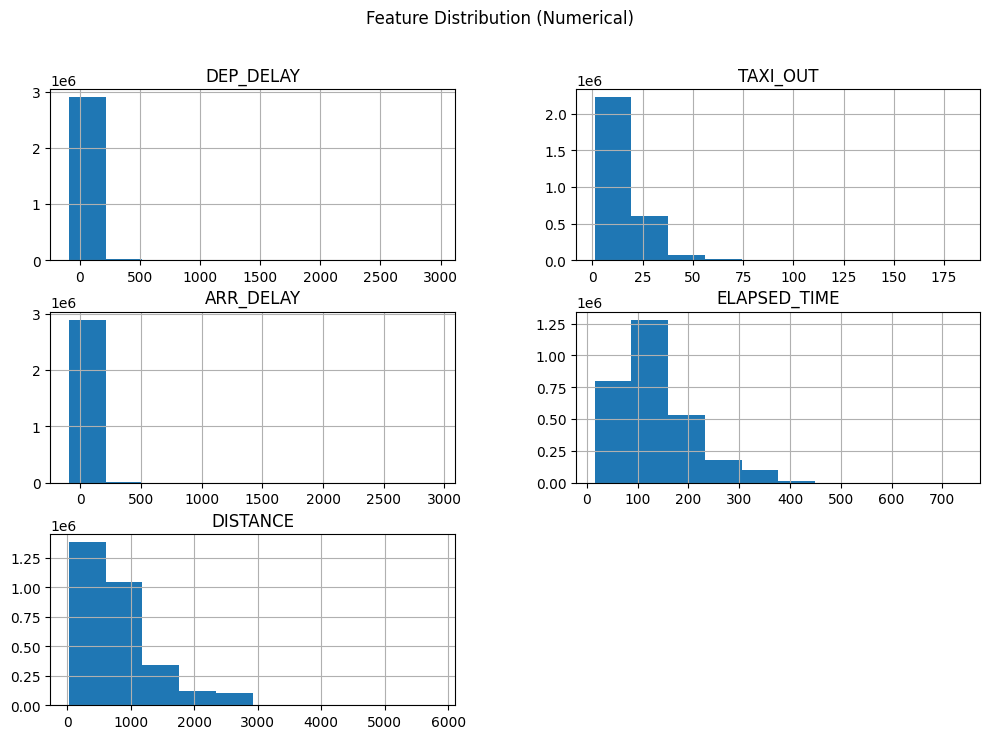

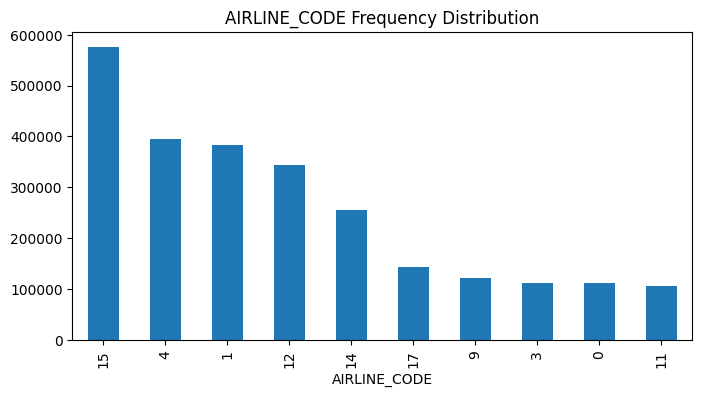

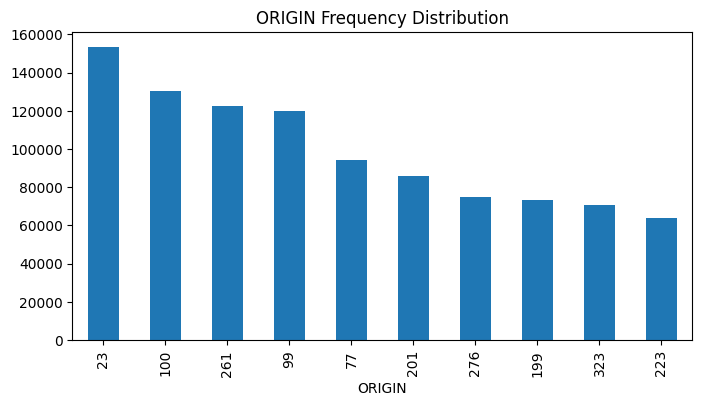

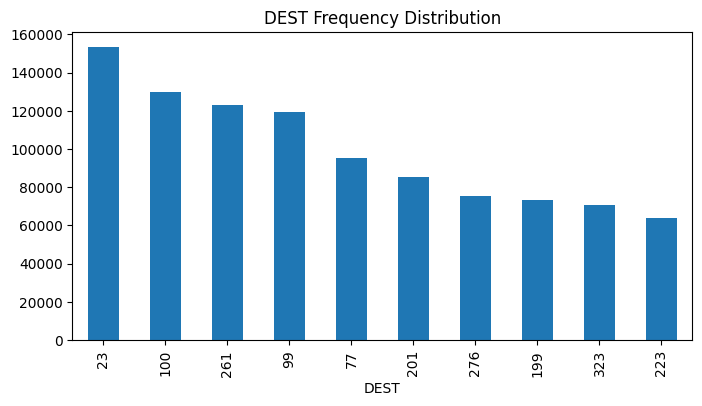

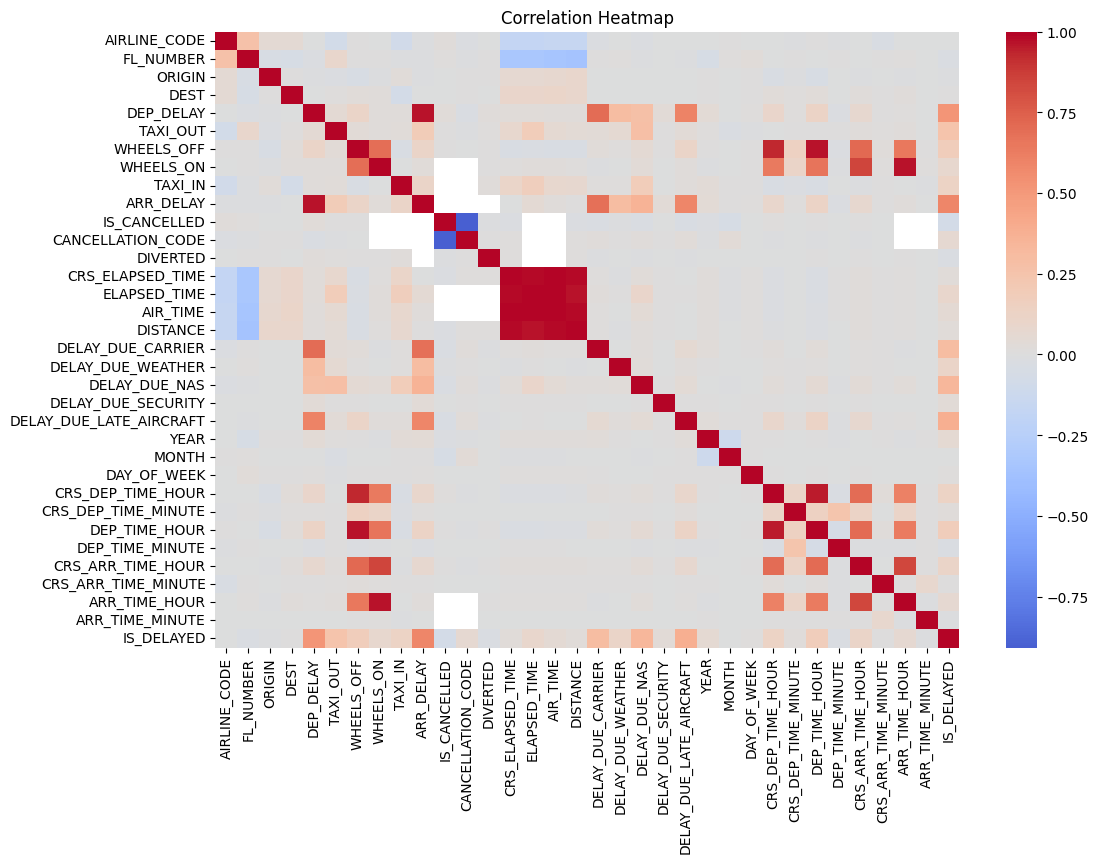

Correlation with IS_DELAYED:
 IS_DELAYED                 1.000000
ARR_DELAY                  0.590162
DEP_DELAY                  0.520313
DELAY_DUE_LATE_AIRCRAFT    0.388789
DELAY_DUE_NAS              0.339093
DELAY_DUE_CARRIER          0.302337
TAXI_OUT                   0.253673
DEP_TIME_HOUR              0.178465
WHEELS_OFF                 0.176111
CRS_DEP_TIME_HOUR          0.133102
TAXI_IN                    0.129988
DELAY_DUE_WEATHER          0.112884
CRS_ARR_TIME_HOUR          0.109077
ELAPSED_TIME               0.089990
WHEELS_ON                  0.076617
CANCELLATION_CODE          0.068010
ARR_TIME_HOUR              0.066609
YEAR                       0.055166
AIR_TIME                   0.047206
DELAY_DUE_SECURITY         0.037053
DISTANCE                   0.028446
CRS_ELAPSED_TIME           0.027693
CRS_DEP_TIME_MINUTE        0.023659
DAY_OF_WEEK                0.014394
DEST                       0.005251
CRS_ARR_TIME_MINUTE        0.005030
MONTH                      0.00140

In [5]:
# selecting correlated features
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# Histograms for key numeric features
numeric_cols = ['DEP_DELAY', 'TAXI_OUT', 'ARR_DELAY', 'ELAPSED_TIME', 'DISTANCE']
df[numeric_cols].hist(figsize=(12, 8))
plt.suptitle("Feature Distribution (Numerical)")
plt.show()

# Bar plots for categorical features
categorical_cols = ['AIRLINE_CODE', 'ORIGIN', 'DEST']
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    df[col].value_counts().head(10).plot(kind='bar')
    plt.title(f"{col} Frequency Distribution")
    plt.show()

# --- 2. Correlation Analysis ---
# Compute correlations with label
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

# Check top correlations with label
corr_target = corr['IS_DELAYED'].sort_values(ascending=False)
print("Correlation with IS_DELAYED:\n", corr_target)


In [ ]:
# Drop all columns that would cause label leakage
# Drop features that leak the target (known only after flight completes)
leakage_cols = [
    'FL_DATE',
    'ARR_DELAY',
    'CANCELLATION_CODE', 
    'IS_CANCELLED',
    'DELAY_DUE_CARRIER',
    'DELAY_DUE_WEATHER',
    'DELAY_DUE_NAS',
    'DELAY_DUE_SECURITY',
    'DELAY_DUE_LATE_AIRCRAFT',
    'ARR_TIME_HOUR',
    'ARR_TIME_MINUTE',
    'ELAPSED_TIME',
    'AIR_TIME',
    'WHEELS_ON'  # Actual landing time - also leakage
]

df_cleaned = df.drop(columns=leakage_cols, errors='ignore')

# Save the cleaned version
df_cleaned.to_csv('flights_cleaned.csv', index=False)

print("✅ Cleaned dataset saved as 'flights_cleaned.csv'")
print("Remaining columns:")
print(df_cleaned.columns.tolist())


✅ Cleaned dataset saved as 'flights_cleaned.csv'
Remaining columns:
['AIRLINE_CODE', 'FL_NUMBER', 'ORIGIN', 'DEST', 'DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'TAXI_IN', 'DIVERTED', 'CRS_ELAPSED_TIME', 'DISTANCE', 'YEAR', 'MONTH', 'DAY_OF_WEEK', 'CRS_DEP_TIME_HOUR', 'CRS_DEP_TIME_MINUTE', 'DEP_TIME_HOUR', 'DEP_TIME_MINUTE', 'CRS_ARR_TIME_HOUR', 'CRS_ARR_TIME_MINUTE', 'IS_DELAYED']


### Phase 3 - Pilot study

###### 1-KNN, 2-Linear Regression, 3-Logistic Regression, 4-Perceptron Learning, 5-Artificial Neural Networks, 6-Decision Trees, 7-Random Forests, 8-Bayesian Learning, and 9-Support Vector Machines.

In [1]:
import pandas as pd
df = pd.read_csv('flights_cleaned.csv')

In [2]:
pd.set_option('display.max_columns', None)
df.head()

,AIRLINE_CODE,FL_NUMBER,ORIGIN,DEST,DEP_DELAY,TAXI_OUT,WHEELS_OFF,TAXI_IN,DIVERTED,CRS_ELAPSED_TIME,DISTANCE,YEAR,MONTH,DAY_OF_WEEK,CRS_DEP_TIME_HOUR,CRS_DEP_TIME_MINUTE,DEP_TIME_HOUR,DEP_TIME_MINUTE,CRS_ARR_TIME_HOUR,CRS_ARR_TIME_MINUTE,IS_DELAYED
0,14,1562,131,123,-4.0,19.0,1210.0,4.0,0.0,186.0,1065.0,2019,1,2,11,55,11.0,51.0,15.0,1.0,0
1,4,1149,247,323,-6.0,9.0,2123.0,38.0,0.0,235.0,1399.0,2022,11,5,21,20,21.0,14.0,23.0,15.0,0
2,14,459,99,247,6.0,20.0,1020.0,5.0,0.0,118.0,680.0,2022,7,4,9,54,10.0,0.0,12.0,52.0,0
3,4,2295,247,325,-1.0,27.0,1635.0,9.0,0.0,260.0,1589.0,2023,3,0,16,9,16.0,8.0,18.0,29.0,1
4,10,407,223,100,-2.0,15.0,1853.0,14.0,0.0,181.0,985.0,2020,2,6,18,40,18.0,38.0,20.0,41.0,0


In [3]:
# Cell 1 (BETTER VERSION): Initial Setup with Smart Missing Value Handling
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Check for missing values
print("="*60)
print("CHECKING FOR MISSING VALUES")
print("="*60)
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum():,}")

# Separate features and target
X = df.drop('IS_DELAYED', axis=1)
y = df['IS_DELAYED']

# Smart missing value handling
print("\n" + "="*60)
print("HANDLING MISSING VALUES")
print("="*60)

# Group 1: Fill with 0 (cancelled/diverted flights - actual values don't exist)
fill_zero_cols = ['DEP_DELAY', 'TAXI_OUT', 'WHEELS_OFF', 'TAXI_IN', 
                   'DEP_TIME_HOUR', 'DEP_TIME_MINUTE']

print("\nFilling with 0 (cancelled/diverted flights):")
for col in fill_zero_cols:
    if col in X.columns:
        missing_count = X[col].isnull().sum()
        X[col].fillna(0, inplace=True)
        print(f"  {col}: {missing_count:,} values → 0")

# Group 2: Fill with median (scheduled times - likely data errors)
fill_median_cols = ['CRS_ELAPSED_TIME', 'CRS_ARR_TIME_HOUR', 'CRS_ARR_TIME_MINUTE']

print("\nFilling with median (scheduled times):")
for col in fill_median_cols:
    if col in X.columns:
        missing_count = X[col].isnull().sum()
        median_val = X[col].median()
        X[col].fillna(median_val, inplace=True)
        print(f"  {col}: {missing_count:,} values → {median_val}")

print(f"\nMissing values after imputation: {X.isnull().sum().sum()}")

# Create train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Display basic information
print("\n" + "="*60)
print("DATASET INFORMATION")
print("="*60)
print(f"Total samples: {len(df):,}")
print(f"Number of features: {X.shape[1]}")
print(f"Training samples: {len(X_train):,}")
print(f"Testing samples: {len(X_test):,}")
print(f"\nTarget distribution (full dataset):")
print(y.value_counts())
print(f"\nTarget distribution proportions:")
print(y.value_counts(normalize=True))
print(f"\nFeatures: {list(X.columns)}")
print("\n" + "="*60)
print("Setup complete! Ready to train models.")
print("="*60)

CHECKING FOR MISSING VALUES
DEP_DELAY              77644
TAXI_OUT               78806
WHEELS_OFF             78806
TAXI_IN                79944
CRS_ELAPSED_TIME          14
DEP_TIME_HOUR          77857
DEP_TIME_MINUTE        77857
CRS_ARR_TIME_HOUR         14
CRS_ARR_TIME_MINUTE       14
dtype: int64

Total missing values: 470,956

HANDLING MISSING VALUES

Filling with 0 (cancelled/diverted flights):
  DEP_DELAY: 77,644 values → 0
  TAXI_OUT: 78,806 values → 0
  WHEELS_OFF: 78,806 values → 0
  TAXI_IN: 79,944 values → 0
  DEP_TIME_HOUR: 77,857 values → 0
  DEP_TIME_MINUTE: 77,857 values → 0

Filling with median (scheduled times):
  CRS_ELAPSED_TIME: 14 values → 125.0
  CRS_ARR_TIME_HOUR: 14 values → 15.0
  CRS_ARR_TIME_MINUTE: 14 values → 30.0

Missing values after imputation: 0

DATASET INFORMATION
Total samples: 3,000,000
Number of features: 20
Training samples: 2,400,000
Testing samples: 600,000

Target distribution (full dataset):
IS_DELAYED
0    2484711
1     515289
Name: count, d

In [8]:
# Cell 2: K-Nearest Neighbors (KNN)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import time

print("="*60)
print("MODEL 1: K-NEAREST NEIGHBORS (KNN)")
print("="*60)

# Scale features (KNN requires scaling)
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize KNN with default parameters (n_neighbors=5)
print("Training KNN model (k=5)...")
start_time = time.time()

knn_model = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# Make predictions
print("\nMaking predictions...")
start_time = time.time()
y_pred = knn_model.predict(X_test_scaled)
y_pred_proba = knn_model.predict_proba(X_test_scaled)[:, 1]
pred_time = time.time() - start_time
print(f"Prediction completed in {pred_time:.2f} seconds")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nTrue Negatives:  {conf_matrix[0,0]:,}")
print(f"False Positives: {conf_matrix[0,1]:,}")
print(f"False Negatives: {conf_matrix[1,0]:,}")
print(f"True Positives:  {conf_matrix[1,1]:,}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print(f"Total training time: {train_time:.2f} seconds")
print(f"Total prediction time: {pred_time:.2f} seconds")
print("="*60)

MODEL 1: K-NEAREST NEIGHBORS (KNN)

Scaling features...
Training KNN model (k=5)...
Training completed in 0.17 seconds

Making predictions...
Prediction completed in 702.21 seconds

PERFORMANCE METRICS
Accuracy:  0.9250
Precision: 0.9107
Recall:    0.6249
F1-Score:  0.7412
ROC-AUC:   0.9234

Confusion Matrix:
[[490627   6315]
 [ 38657  64401]]

True Negatives:  490,627
False Positives: 6,315
False Negatives: 38,657
True Positives:  64,401

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Delayed       0.93      0.99      0.96    496942
     Delayed       0.91      0.62      0.74    103058

    accuracy                           0.93    600000
   macro avg       0.92      0.81      0.85    600000
weighted avg       0.92      0.93      0.92    600000

Total training time: 0.17 seconds
Total prediction time: 702.21 seconds


In [9]:
# Cell 3: Linear Regression (for comparison with classification models)
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import time

print("="*60)
print("MODEL 2: LINEAR REGRESSION")
print("="*60)
print("Note: Linear Regression is designed for continuous targets,")
print("but we'll use it here with thresholding (>= 0.5 → Delayed)")

# Scale features
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Linear Regression
print("Training Linear Regression model...")
start_time = time.time()

linreg_model = LinearRegression(n_jobs=-1)
linreg_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# Make predictions
print("\nMaking predictions...")
start_time = time.time()
y_pred_continuous = linreg_model.predict(X_test_scaled)

# Apply threshold: >= 0.5 means delayed
y_pred = (y_pred_continuous >= 0.5).astype(int)
pred_time = time.time() - start_time
print(f"Prediction completed in {pred_time:.2f} seconds")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_continuous)  # Use continuous scores for ROC-AUC
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nTrue Negatives:  {conf_matrix[0,0]:,}")
print(f"False Positives: {conf_matrix[0,1]:,}")
print(f"False Negatives: {conf_matrix[1,0]:,}")
print(f"True Positives:  {conf_matrix[1,1]:,}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print(f"Total training time: {train_time:.2f} seconds")
print(f"Total prediction time: {pred_time:.2f} seconds")
print("="*60)

MODEL 2: LINEAR REGRESSION
Note: Linear Regression is designed for continuous targets,
but we'll use it here with thresholding (>= 0.5 → Delayed)

Scaling features...
Training Linear Regression model...
Training completed in 0.65 seconds

Making predictions...
Prediction completed in 0.02 seconds

PERFORMANCE METRICS
Accuracy:  0.8780
Precision: 0.9907
Recall:    0.2925
F1-Score:  0.4516
ROC-AUC:   0.9538

Confusion Matrix:
[[496658    284]
 [ 72916  30142]]

True Negatives:  496,658
False Positives: 284
False Negatives: 72,916
True Positives:  30,142

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Delayed       0.87      1.00      0.93    496942
     Delayed       0.99      0.29      0.45    103058

    accuracy                           0.88    600000
   macro avg       0.93      0.65      0.69    600000
weighted avg       0.89      0.88      0.85    600000

Total training time: 0.65 seconds
Total prediction time: 0.02 seconds


In [10]:
# Cell 4: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import time

print("="*60)
print("MODEL 3: LOGISTIC REGRESSION")
print("="*60)

# Scale features (recommended for Logistic Regression)
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Logistic Regression with default parameters
print("Training Logistic Regression model...")
start_time = time.time()

logreg_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
logreg_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# Make predictions
print("\nMaking predictions...")
start_time = time.time()
y_pred = logreg_model.predict(X_test_scaled)
y_pred_proba = logreg_model.predict_proba(X_test_scaled)[:, 1]
pred_time = time.time() - start_time
print(f"Prediction completed in {pred_time:.2f} seconds")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nTrue Negatives:  {conf_matrix[0,0]:,}")
print(f"False Positives: {conf_matrix[0,1]:,}")
print(f"False Negatives: {conf_matrix[1,0]:,}")
print(f"True Positives:  {conf_matrix[1,1]:,}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print(f"Total training time: {train_time:.2f} seconds")
print(f"Total prediction time: {pred_time:.2f} seconds")
print("="*60)

MODEL 3: LOGISTIC REGRESSION

Scaling features...
Training Logistic Regression model...
Training completed in 4.31 seconds

Making predictions...
Prediction completed in 0.02 seconds

PERFORMANCE METRICS
Accuracy:  0.9584
Precision: 0.9209
Recall:    0.8288
F1-Score:  0.8724
ROC-AUC:   0.9772

Confusion Matrix:
[[489609   7333]
 [ 17643  85415]]

True Negatives:  489,609
False Positives: 7,333
False Negatives: 17,643
True Positives:  85,415

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Delayed       0.97      0.99      0.98    496942
     Delayed       0.92      0.83      0.87    103058

    accuracy                           0.96    600000
   macro avg       0.94      0.91      0.92    600000
weighted avg       0.96      0.96      0.96    600000

Total training time: 4.31 seconds
Total prediction time: 0.02 seconds


In [ ]:
# Cell 5: Perceptron Learning
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
import time

print("="*60)
print("MODEL 4: PERCEPTRON LEARNING")
print("="*60)

# Scale features (Perceptron requires scaling)
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Perceptron with default parameters
print("Training Perceptron model...")
start_time = time.time()

perceptron_model = Perceptron(random_state=42, n_jobs=-1)
perceptron_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# Make predictions
print("\nMaking predictions...")
start_time = time.time()
y_pred = perceptron_model.predict(X_test_scaled)
# Note: Perceptron doesn't have predict_proba by default, we'll use decision_function
y_pred_scores = perceptron_model.decision_function(X_test_scaled)
pred_time = time.time() - start_time
print(f"Prediction completed in {pred_time:.2f} seconds")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_scores)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nTrue Negatives:  {conf_matrix[0,0]:,}")
print(f"False Positives: {conf_matrix[0,1]:,}")
print(f"False Negatives: {conf_matrix[1,0]:,}")
print(f"True Positives:  {conf_matrix[1,1]:,}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print(f"Total training time: {train_time:.2f} seconds")
print(f"Total prediction time: {pred_time:.2f} seconds")
print("="*60)

MODEL 4: PERCEPTRON LEARNING

Scaling features...
Training Perceptron model...
Training completed in 2.09 seconds

Making predictions...
Prediction completed in 0.01 seconds

PERFORMANCE METRICS
Accuracy:  0.9278
Precision: 0.7816
Recall:    0.8049
F1-Score:  0.7930
ROC-AUC:   0.9535

Confusion Matrix:
[[473762  23180]
 [ 20111  82947]]

True Negatives:  473,762
False Positives: 23,180
False Negatives: 20,111
True Positives:  82,947

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Delayed       0.96      0.95      0.96    496942
     Delayed       0.78      0.80      0.79    103058

    accuracy                           0.93    600000
   macro avg       0.87      0.88      0.87    600000
weighted avg       0.93      0.93      0.93    600000

Total training time: 2.09 seconds
Total prediction time: 0.01 seconds


In [12]:
# Cell 6: Artificial Neural Networks (Multi-Layer Perceptron)
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
import time

print("="*60)
print("MODEL 5: ARTIFICIAL NEURAL NETWORKS (MLP)")
print("="*60)

# Scale features (critical for ANN)
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize MLP with default parameters (one hidden layer with 100 neurons)
print("Training Neural Network model...")
print("Architecture: Input(20) -> Hidden(100) -> Output(2)")
start_time = time.time()

ann_model = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=300,
    random_state=42,
    verbose=False
)
ann_model.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# Make predictions
print("\nMaking predictions...")
start_time = time.time()
y_pred = ann_model.predict(X_test_scaled)
y_pred_proba = ann_model.predict_proba(X_test_scaled)[:, 1]
pred_time = time.time() - start_time
print(f"Prediction completed in {pred_time:.2f} seconds")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nTrue Negatives:  {conf_matrix[0,0]:,}")
print(f"False Positives: {conf_matrix[0,1]:,}")
print(f"False Negatives: {conf_matrix[1,0]:,}")
print(f"True Positives:  {conf_matrix[1,1]:,}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print(f"Total training time: {train_time:.2f} seconds")
print(f"Total prediction time: {pred_time:.2f} seconds")
print(f"Number of iterations: {ann_model.n_iter_}")
print("="*60)

MODEL 5: ARTIFICIAL NEURAL NETWORKS (MLP)

Scaling features...
Training Neural Network model...
Architecture: Input(20) -> Hidden(100) -> Output(2)
Training completed in 141.68 seconds

Making predictions...
Prediction completed in 0.76 seconds

PERFORMANCE METRICS
Accuracy:  0.9631
Precision: 0.9349
Recall:    0.8438
F1-Score:  0.8870
ROC-AUC:   0.9835

Confusion Matrix:
[[490889   6053]
 [ 16098  86960]]

True Negatives:  490,889
False Positives: 6,053
False Negatives: 16,098
True Positives:  86,960

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Delayed       0.97      0.99      0.98    496942
     Delayed       0.93      0.84      0.89    103058

    accuracy                           0.96    600000
   macro avg       0.95      0.92      0.93    600000
weighted avg       0.96      0.96      0.96    600000

Total training time: 141.68 seconds
Total prediction time: 0.76 seconds
Number of iterations: 27


In [13]:
# Cell 7: Decision Trees
from sklearn.tree import DecisionTreeClassifier
import time

print("="*60)
print("MODEL 6: DECISION TREES")
print("="*60)

# Decision Trees don't require scaling
print("Training Decision Tree model...")
start_time = time.time()

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# Make predictions
print("\nMaking predictions...")
start_time = time.time()
y_pred = dt_model.predict(X_test)
y_pred_proba = dt_model.predict_proba(X_test)[:, 1]
pred_time = time.time() - start_time
print(f"Prediction completed in {pred_time:.2f} seconds")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nTrue Negatives:  {conf_matrix[0,0]:,}")
print(f"False Positives: {conf_matrix[0,1]:,}")
print(f"False Negatives: {conf_matrix[1,0]:,}")
print(f"True Positives:  {conf_matrix[1,1]:,}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print(f"Total training time: {train_time:.2f} seconds")
print(f"Total prediction time: {pred_time:.2f} seconds")
print(f"Tree depth: {dt_model.get_depth()}")
print(f"Number of leaves: {dt_model.get_n_leaves()}")
print("="*60)

MODEL 6: DECISION TREES
Training Decision Tree model...
Training completed in 27.85 seconds

Making predictions...
Prediction completed in 0.22 seconds

PERFORMANCE METRICS
Accuracy:  0.9336
Precision: 0.7984
Recall:    0.8204
F1-Score:  0.8093
ROC-AUC:   0.8887

Confusion Matrix:
[[475599  21343]
 [ 18509  84549]]

True Negatives:  475,599
False Positives: 21,343
False Negatives: 18,509
True Positives:  84,549

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Delayed       0.96      0.96      0.96    496942
     Delayed       0.80      0.82      0.81    103058

    accuracy                           0.93    600000
   macro avg       0.88      0.89      0.88    600000
weighted avg       0.93      0.93      0.93    600000

Total training time: 27.85 seconds
Total prediction time: 0.22 seconds
Tree depth: 49
Number of leaves: 96898


In [14]:
# Cell 8: Random Forests
from sklearn.ensemble import RandomForestClassifier
import time

print("="*60)
print("MODEL 7: RANDOM FORESTS")
print("="*60)

# Random Forest doesn't require scaling
print("Training Random Forest model (100 trees)...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# Make predictions
print("\nMaking predictions...")
start_time = time.time()
y_pred = rf_model.predict(X_test)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]
pred_time = time.time() - start_time
print(f"Prediction completed in {pred_time:.2f} seconds")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nTrue Negatives:  {conf_matrix[0,0]:,}")
print(f"False Positives: {conf_matrix[0,1]:,}")
print(f"False Negatives: {conf_matrix[1,0]:,}")
print(f"True Positives:  {conf_matrix[1,1]:,}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print(f"Total training time: {train_time:.2f} seconds")
print(f"Total prediction time: {pred_time:.2f} seconds")
print("="*60)

MODEL 7: RANDOM FORESTS
Training Random Forest model (100 trees)...
Training completed in 50.64 seconds

Making predictions...
Prediction completed in 1.94 seconds

PERFORMANCE METRICS
Accuracy:  0.9575
Precision: 0.9203
Recall:    0.8237
F1-Score:  0.8693
ROC-AUC:   0.9781

Confusion Matrix:
[[489590   7352]
 [ 18169  84889]]

True Negatives:  489,590
False Positives: 7,352
False Negatives: 18,169
True Positives:  84,889

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Delayed       0.96      0.99      0.97    496942
     Delayed       0.92      0.82      0.87    103058

    accuracy                           0.96    600000
   macro avg       0.94      0.90      0.92    600000
weighted avg       0.96      0.96      0.96    600000

Total training time: 50.64 seconds
Total prediction time: 1.94 seconds


In [6]:
# Cell 9 (REVISED): Naive Bayes (Bayesian Learning) - WITHOUT SCALING
from sklearn.naive_bayes import GaussianNB
import time

print("="*60)
print("MODEL 8: NAIVE BAYES (BAYESIAN LEARNING) - REVISED")
print("="*60)

# Try WITHOUT scaling (Naive Bayes works on original distributions)
print("Training Naive Bayes model (without scaling)...")
start_time = time.time()

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# Make predictions
print("\nMaking predictions...")
start_time = time.time()
y_pred = nb_model.predict(X_test)
y_pred_proba = nb_model.predict_proba(X_test)[:, 1]
pred_time = time.time() - start_time
print(f"Prediction completed in {pred_time:.2f} seconds")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nTrue Negatives:  {conf_matrix[0,0]:,}")
print(f"False Positives: {conf_matrix[0,1]:,}")
print(f"False Negatives: {conf_matrix[1,0]:,}")
print(f"True Positives:  {conf_matrix[1,1]:,}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print(f"Total training time: {train_time:.2f} seconds")
print(f"Total prediction time: {pred_time:.2f} seconds")
print("="*60)

MODEL 8: NAIVE BAYES (BAYESIAN LEARNING) - REVISED
Training Naive Bayes model (without scaling)...
Training completed in 0.43 seconds

Making predictions...
Prediction completed in 0.20 seconds

PERFORMANCE METRICS
Accuracy:  0.9370
Precision: 0.8225
Recall:    0.8073
F1-Score:  0.8148
ROC-AUC:   0.9532

Confusion Matrix:
[[478990  17952]
 [ 19861  83197]]

True Negatives:  478,990
False Positives: 17,952
False Negatives: 19,861
True Positives:  83,197

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Delayed       0.96      0.96      0.96    496942
     Delayed       0.82      0.81      0.81    103058

    accuracy                           0.94    600000
   macro avg       0.89      0.89      0.89    600000
weighted avg       0.94      0.94      0.94    600000

Total training time: 0.43 seconds
Total prediction time: 0.20 seconds


In [ ]:
# Cell 10 (ALTERNATIVE): Linear SVM - Much Faster
from sklearn.svm import LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV
import time

print("="*60)
print("MODEL 9: SUPPORT VECTOR MACHINES (Linear SVM)")
print("="*60)
print("Note: Using LinearSVC for computational efficiency")

# Scale features (critical for SVM)
print("\nScaling features...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize Linear SVM
print("Training Linear SVM model...")
start_time = time.time()

svm_model = LinearSVC(random_state=42, max_iter=1000)
svm_model.fit(X_train_scaled, y_train)

# Calibrate for probability predictions
print("Calibrating for probability estimates...")
svm_calibrated = CalibratedClassifierCV(svm_model, cv=3)
svm_calibrated.fit(X_train_scaled, y_train)

train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds")

# Make predictions
print("\nMaking predictions...")
start_time = time.time()
y_pred = svm_calibrated.predict(X_test_scaled)
y_pred_proba = svm_calibrated.predict_proba(X_test_scaled)[:, 1]
pred_time = time.time() - start_time
print(f"Prediction completed in {pred_time:.2f} seconds")

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print("\n" + "="*60)
print("PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nTrue Negatives:  {conf_matrix[0,0]:,}")
print(f"False Positives: {conf_matrix[0,1]:,}")
print(f"False Negatives: {conf_matrix[1,0]:,}")
print(f"True Positives:  {conf_matrix[1,1]:,}")

print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Not Delayed', 'Delayed']))

print("="*60)
print(f"Total training time: {train_time:.2f} seconds")
print(f"Total prediction time: {pred_time:.2f} seconds")
print("="*60)

MODEL 9: SUPPORT VECTOR MACHINES (Linear SVM)
Note: Using LinearSVC for computational efficiency

Scaling features...
Training Linear SVM model...
Calibrating for probability estimates...
Training completed in 28.89 seconds

Making predictions...
Prediction completed in 0.11 seconds

PERFORMANCE METRICS
Accuracy:  0.9582
Precision: 0.9206
Recall:    0.8280
F1-Score:  0.8719
ROC-AUC:   0.9770

Confusion Matrix:
[[489578   7364]
 [ 17722  85336]]

True Negatives:  489,578
False Positives: 7,364
False Negatives: 17,722
True Positives:  85,336

CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Not Delayed       0.97      0.99      0.98    496942
     Delayed       0.92      0.83      0.87    103058

    accuracy                           0.96    600000
   macro avg       0.94      0.91      0.92    600000
weighted avg       0.96      0.96      0.96    600000

Total training time: 28.89 seconds
Total prediction time: 0.11 seconds


COMPREHENSIVE MODEL COMPARISON

📊 MODELS RANKED BY F1-SCORE:

               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Time (s)  Pred Time (s)
Neural Network (MLP)    0.9631     0.9349  0.8438    0.8870   0.9835          141.68           0.76
 Logistic Regression    0.9584     0.9209  0.8288    0.8724   0.9772            4.31           0.02
          Linear SVM    0.9582     0.9206  0.8280    0.8719   0.9770           28.89           0.11
       Random Forest    0.9575     0.9203  0.8237    0.8693   0.9781           50.64           1.94
         Naive Bayes    0.9370     0.8225  0.8073    0.8148   0.9532            0.43           0.20
       Decision Tree    0.9336     0.7984  0.8204    0.8093   0.8887           27.85           0.22
          Perceptron    0.9278     0.7816  0.8049    0.7930   0.9535            2.09           0.01
                 KNN    0.9250     0.9107  0.6249    0.7412   0.9234            0.17         702.21
   Linear Regression    0.8780     0.9

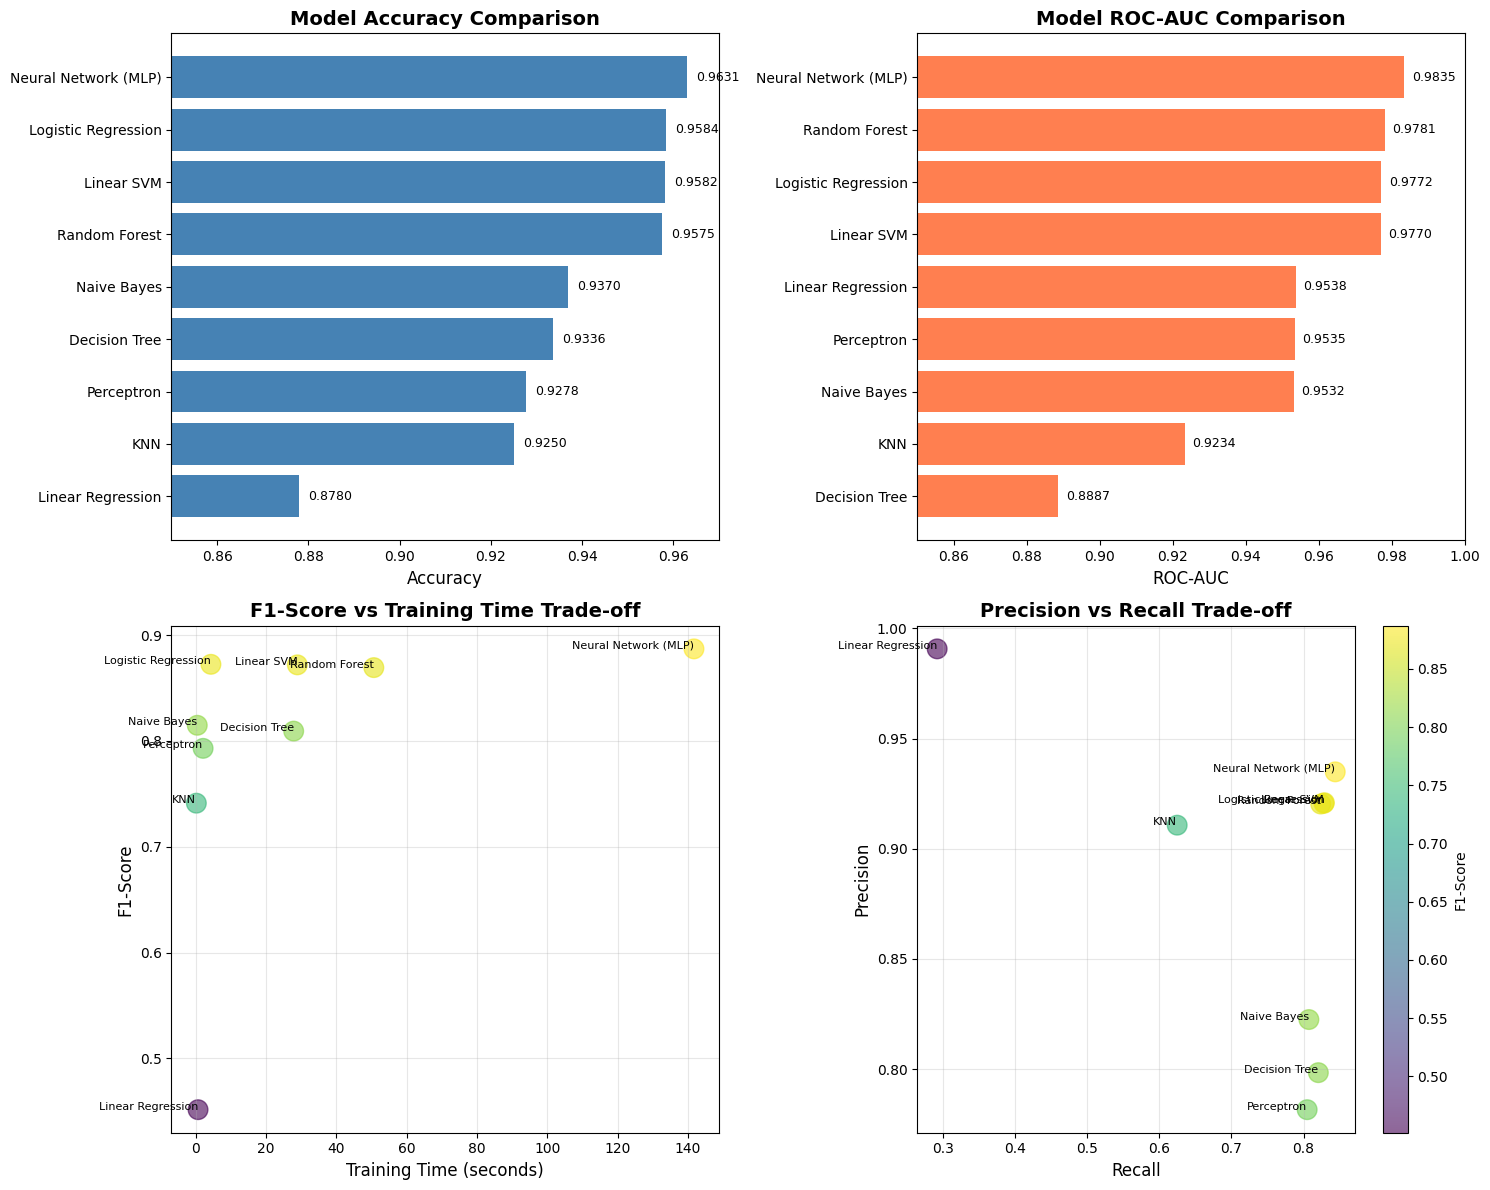


✅ Visualization saved as 'model_comparison.png'


In [6]:
# Cell 11: Model Comparison Summary
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("="*70)
print("COMPREHENSIVE MODEL COMPARISON")
print("="*70)

# Create summary dataframe
results = {
    'Model': ['KNN', 'Linear Regression', 'Logistic Regression', 'Perceptron', 
              'Neural Network (MLP)', 'Decision Tree', 'Random Forest', 
              'Naive Bayes', 'Linear SVM'],
    'Accuracy': [0.9250, 0.8780, 0.9584, 0.9278, 0.9631, 0.9336, 0.9575, 0.9370, 0.9582],
    'Precision': [0.9107, 0.9907, 0.9209, 0.7816, 0.9349, 0.7984, 0.9203, 0.8225, 0.9206],
    'Recall': [0.6249, 0.2925, 0.8288, 0.8049, 0.8438, 0.8204, 0.8237, 0.8073, 0.8280],
    'F1-Score': [0.7412, 0.4516, 0.8724, 0.7930, 0.8870, 0.8093, 0.8693, 0.8148, 0.8719],
    'ROC-AUC': [0.9234, 0.9538, 0.9772, 0.9535, 0.9835, 0.8887, 0.9781, 0.9532, 0.9770],
    'Train Time (s)': [0.17, 0.65, 4.31, 2.09, 141.68, 27.85, 50.64, 0.43, 28.89],
    'Pred Time (s)': [702.21, 0.02, 0.02, 0.01, 0.76, 0.22, 1.94, 0.20, 0.11]
}

df_results = pd.DataFrame(results)

# Sort by F1-Score (balanced metric)
df_sorted = df_results.sort_values('F1-Score', ascending=False)

print("\n📊 MODELS RANKED BY F1-SCORE:\n")
print(df_sorted.to_string(index=False))

print("\n" + "="*70)
print("TOP 3 MODELS:")
print("="*70)
top3 = df_sorted.head(3)
for idx, row in top3.iterrows():
    print(f"\n{row['Model']}:")
    print(f"  • Accuracy:  {row['Accuracy']:.4f}")
    print(f"  • Precision: {row['Precision']:.4f}")
    print(f"  • Recall:    {row['Recall']:.4f}")
    print(f"  • F1-Score:  {row['F1-Score']:.4f}")
    print(f"  • ROC-AUC:   {row['ROC-AUC']:.4f}")
    print(f"  • Training:  {row['Train Time (s)']:.2f}s")

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Accuracy Comparison
ax1 = axes[0, 0]
df_sorted_acc = df_results.sort_values('Accuracy', ascending=True)
ax1.barh(df_sorted_acc['Model'], df_sorted_acc['Accuracy'], color='steelblue')
ax1.set_xlabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_xlim([0.85, 0.97])
for i, v in enumerate(df_sorted_acc['Accuracy']):
    ax1.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 2: ROC-AUC Comparison
ax2 = axes[0, 1]
df_sorted_roc = df_results.sort_values('ROC-AUC', ascending=True)
ax2.barh(df_sorted_roc['Model'], df_sorted_roc['ROC-AUC'], color='coral')
ax2.set_xlabel('ROC-AUC', fontsize=12)
ax2.set_title('Model ROC-AUC Comparison', fontsize=14, fontweight='bold')
ax2.set_xlim([0.85, 1.0])
for i, v in enumerate(df_sorted_roc['ROC-AUC']):
    ax2.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

# Plot 3: F1-Score vs Training Time
ax3 = axes[1, 0]
scatter = ax3.scatter(df_results['Train Time (s)'], df_results['F1-Score'], 
                     s=200, alpha=0.6, c=df_results['F1-Score'], cmap='viridis')
for i, model in enumerate(df_results['Model']):
    ax3.annotate(model, (df_results['Train Time (s)'][i], df_results['F1-Score'][i]),
                fontsize=8, ha='right')
ax3.set_xlabel('Training Time (seconds)', fontsize=12)
ax3.set_ylabel('F1-Score', fontsize=12)
ax3.set_title('F1-Score vs Training Time Trade-off', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3)

# Plot 4: Precision vs Recall
ax4 = axes[1, 1]
scatter = ax4.scatter(df_results['Recall'], df_results['Precision'], 
                     s=200, alpha=0.6, c=df_results['F1-Score'], cmap='viridis')
for i, model in enumerate(df_results['Model']):
    ax4.annotate(model, (df_results['Recall'][i], df_results['Precision'][i]),
                fontsize=8, ha='right')
ax4.set_xlabel('Recall', fontsize=12)
ax4.set_ylabel('Precision', fontsize=12)
ax4.set_title('Precision vs Recall Trade-off', fontsize=14, fontweight='bold')
ax4.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax4, label='F1-Score')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*70)
print("✅ Visualization saved as 'model_comparison.png'")
print("="*70)